# Multi-objective optimization

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from smt.sampling_methods import LHS
from smt_optim.core import Driver, ObjectiveConfig, ConstraintConfig, DriverConfig, Problem

from smt_optim.surrogate_models.smt import SmtAutoModel

from smt_optim.acquisition_strategies.multiobj import MultiObj
from smt_optim.acquisition_functions.multi_obj import get_pareto_front, init_mpi

from smt_optim.benchmarks.registry import get_problem
from smt_optim.utils.plot_2d import get_plot2d_data


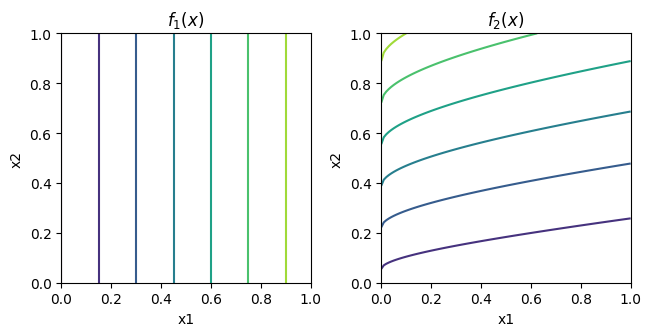

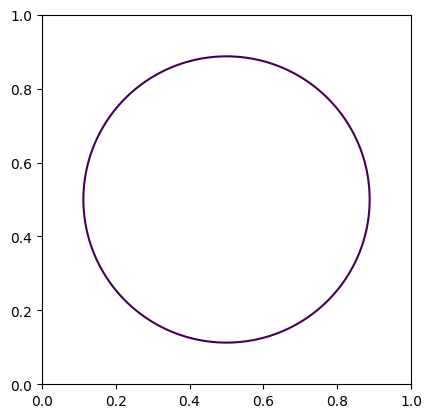

In [2]:

problem = get_problem("ZDT1")

problem.set_dim(2)

x1 = np.linspace(0, 1, 101)
x2 = np.linspace(0, 1, 101)

XX, YY = np.meshgrid(x1, x2)

data = np.vstack((XX.ravel(), YY.ravel())).T
f1 = np.empty(data.shape[0])
f2 = np.empty(data.shape[0])

for i in range(data.shape[0]):
    f1[i] = problem.f1(data[i, :])
    f2[i] = problem.f2(data[i, :])

F1 = f1.reshape(XX.shape)
F2 = f2.reshape(XX.shape)

fig, ax = plt.subplots(1, 2, layout="constrained")
ax[0].set_title(r"$f_1(x)$")
ax[0].contour(XX, YY, F1)
ax[1].set_title(r"$f_2(x)$")
ax[1].contour(XX, YY, F2)

for idx in range(2):
    ax[idx].set_xlabel("x1")
    ax[idx].set_ylabel("x2")
    ax[idx].set_aspect("equal")

plt.show()




def g(x):
    return (x[0] - 0.5)**2 + (x[1] - 0.5)**2 - 0.15

XX, YY, GG = get_plot2d_data(g, problem.bounds)

fig, ax = plt.subplots()

ax.contour(XX, YY, GG, levels=[0])
ax.set_aspect("equal")

plt.show()



In [3]:
obj_config = ObjectiveConfig(
    [problem.f1],
    type="minimize",
    surrogate=SmtAutoModel,
)

obj_config2 = ObjectiveConfig(
    [problem.f2],
    type="minimize",
    surrogate=SmtAutoModel,
)

# cstr_config = ConstraintConfig(
#     [g],
#     upper=0.,
#     surrogate=SmtAutoModel,
# )

prob_definition = Problem(
    obj_configs=[obj_config, obj_config2],
    # cstr_configs=[cstr_config],
    design_space=problem.bounds,            # problem bounds
)

nt_init = 6

opt_config = DriverConfig(
    max_iter = 50,
    nt_init = nt_init,
    verbose = True,
    scaling = True,
    seed=0,
)

# np.seterr(all="raise")

# driver = Driver(prob_definition, opt_config, MultiObj, strategy_kwargs={"acq_func": init_mpi, "n_start": 1000, "sp_method": None})
driver = Driver(prob_definition, opt_config, MultiObj, strategy_kwargs={"acq_func": init_mpi, "n_start": 40, "sp_method": "Cobyla"})


In [4]:
state = driver.optimize()

          iter         budget             HV       fidelity        gp_time       acq_time
             0              6    4.95980e+00            nan            nan            nan
             1              7    5.09295e+00              1          0.526          0.731
             2              8    5.80462e+00              1          0.423          0.701
             3              9    6.57614e+00              1          0.407          1.010
             4             10    6.58074e+00              1          0.385          1.930
             5             11    6.58609e+00              1          0.495          3.061
             6             12    6.58611e+00              1          0.388          2.126
             7             13    6.58722e+00              1          0.463          1.959
             8             14    6.64610e+00              1          0.300          1.310
             9             15    6.70601e+00              1          0.403          3.337
          

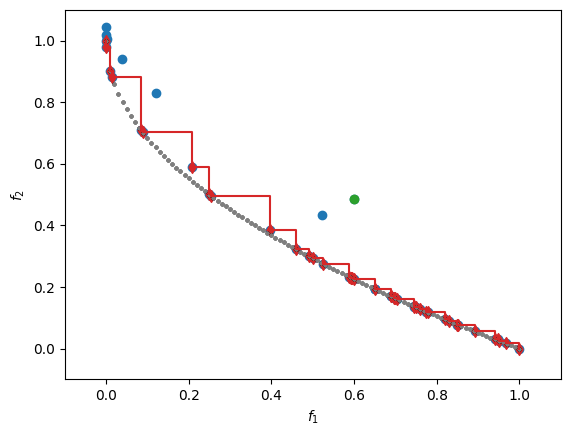

In [5]:

# ======= Optimization Pareto Front =======
data = driver.state.dataset.export_as_dict()
obj = data["obj"]
obj_par = get_pareto_front(obj)

# ======= Solution Pareto Front =======
x1 = np.linspace(0, 1, 101)
x2 = np.linspace(0, 0, 101)

XX, YY = np.meshgrid(x1, x2)

data = np.vstack((XX.ravel(), YY.ravel())).T
f1 = np.empty(data.shape[0])
f2 = np.empty(data.shape[0])

for i in range(data.shape[0]):
    f1[i] = problem.f1(data[i, :])
    f2[i] = problem.f2(data[i, :])

F1 = f1.reshape(XX.shape)
F2 = f2.reshape(XX.shape)

ref_pareto = get_pareto_front(np.vstack((f1, f2)).T)

# ======= Plot optimization and solution pareto front =======
fig, ax = plt.subplots()

ax.scatter(obj[:, 0], obj[:, 1])
ax.scatter(obj[:nt_init, 0], obj[:nt_init, 1], color="C2")
ax.scatter(obj_par[:, 0], obj_par[:, 1], marker="d", color="C3")

sorted_idx = np.argsort(obj_par[:, 0])
obj_par = obj_par[sorted_idx, :]

# PF obtained through optimization
ax.step(obj_par[:, 0], obj_par[:, 1], where="post", color="C3", zorder=20)

# Solution PF
# ax.scatter(F1, F2, 2, color="C7", alpha=0.2, zorder=10)
ax.scatter(ref_pareto[:, 0], ref_pareto[:, 1], 2, color="C7", alpha=0.2, zorder=10)

ax.set_xlabel(r"$f_1$")
ax.set_ylabel(r"$f_2$")

ax.set_xlim((-0.1, 1.1))
ax.set_ylim((-0.1, 1.1))

plt.show()
